In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys

sys.path.insert(0, str(Path("../../scripts").resolve()))
import graph_export
import paths

FONTSIZE = 14
plt.rcParams.update({'font.size': FONTSIZE})

In [25]:
RAW_DIR = paths.exist("data/0_raw", 3)
IGNORE_PATH = paths.edit("results/1_process/1_filter/ignored_files.csv", 3)
STATS_PATH = paths.edit("results/1_process/3_truncate/statistics.csv", 3)
SHORTCUTS_PATH = paths.edit("src/1_process/0_download/leipzig/lepzig_shortcuts.csv", 3)

SOURCE_MARKERS = {"_bible": "Bible", "-ud": "UD", "_glot500_": "Glot500"}
LEIPZIG_SOURCE_NAMES = {
    "wikipedia": "Wikipedia",
    "news": "News",
    "newscrawl": "Newscrawl",
    "community": "Community",
    "web": "Web",
    "mixed": "Mixed",
}
EXTRA_SOURCES = ["Glot500", "Bible", "UD"]

SOURCE_COLORS = {
    "Leipzig": "steelblue",
    "Glot500": "plum",
    "Bible": "goldenrod",
    "UD": "forestgreen",
    "News": "coral",
    "Newscrawl": "salmon",
    "Web": "mediumpurple",
    "Wikipedia": "steelblue",
    "Mixed": "lightblue",
    "Community": "khaki",
    "Other": "gray",
}


def source_from_name(path: Path) -> str:
    stem = path.stem
    for marker, source in SOURCE_MARKERS.items():
        if marker in stem:
            return source
    parts = stem.split("_", 2)
    return LEIPZIG_SOURCE_NAMES.get(parts[1], "Other") if len(parts) > 1 else "Other"


ignored = set(pd.read_csv(IGNORE_PATH)["filename"])
file_rows = [
    {"lang": p.stem.split("-")[0][:3], "source": source_from_name(p), "bytes": p.stat().st_size}
    for p in RAW_DIR.glob("*.csv") if p.name not in ignored
]

size_by_source = pd.DataFrame(file_rows).pivot_table(
    index="lang", columns="source", values="bytes", aggfunc="sum", fill_value=0,
)
all_sources = sorted(size_by_source.columns)
LEIPZIG_SOURCES = [s for s in all_sources if s not in set(EXTRA_SOURCES)]

stats = pd.read_csv(STATS_PATH)
stats["lang"] = stats["file"].str[:3]
totals = stats.groupby("lang")["total_frequency"].sum()
names = pd.read_csv(SHORTCUTS_PATH).set_index("code")["language"]

df_sources = size_by_source.join(totals.rename("total"), how="inner")
source_share = df_sources[all_sources].div(df_sources[all_sources].sum(axis=1), axis=0)
df_sources[all_sources] = source_share.mul(df_sources["total"], axis=0).round().astype(int)

df_sources.insert(0, "name", [names.get(lang, lang) for lang in df_sources.index])
df_sources = df_sources.reset_index().rename(columns={"index": "lang"})

extra_cols = [s for s in EXTRA_SOURCES + ["TIL"] if s in df_sources.columns]
df_sources["extra"] = df_sources[extra_cols].sum(axis=1)
df_sources["existing"] = df_sources["total"] - df_sources["extra"]
df_sources["ratio"] = np.where(
    df_sources["existing"] > 0, df_sources["total"] / df_sources["existing"], np.nan,
)

print(f"Loaded {len(df_sources)} languages, {len(all_sources)} source categories: {', '.join(all_sources)}")
total_all = df_sources["total"].sum()
print(f"Total tokens across all sources: {total_all:,.0f}")
for source in all_sources:
    tc = df_sources[source].sum()
    print(f"  {source:12s}: {tc:>15,} tokens  ({tc / total_all * 100:5.2f}%)")

Loaded 442 languages, 10 source categories: Bible, Community, Glot500, Mixed, News, Newscrawl, Other, UD, Web, Wikipedia
Total tokens across all sources: 94,468,535,583
  Bible       :      87,998,126 tokens  ( 0.09%)
  Community   :     510,094,280 tokens  ( 0.54%)
  Glot500     :  29,325,740,484 tokens  (31.04%)
  Mixed       :   5,543,581,313 tokens  ( 5.87%)
  News        :  25,633,813,339 tokens  (27.13%)
  Newscrawl   :   4,613,563,040 tokens  ( 4.88%)
  Other       :  11,524,351,649 tokens  (12.20%)
  UD          :     201,866,924 tokens  ( 0.21%)
  Web         :  11,122,152,692 tokens  (11.77%)
  Wikipedia   :   5,905,373,723 tokens  ( 6.25%)


graph_export: saved data_sources.pdf


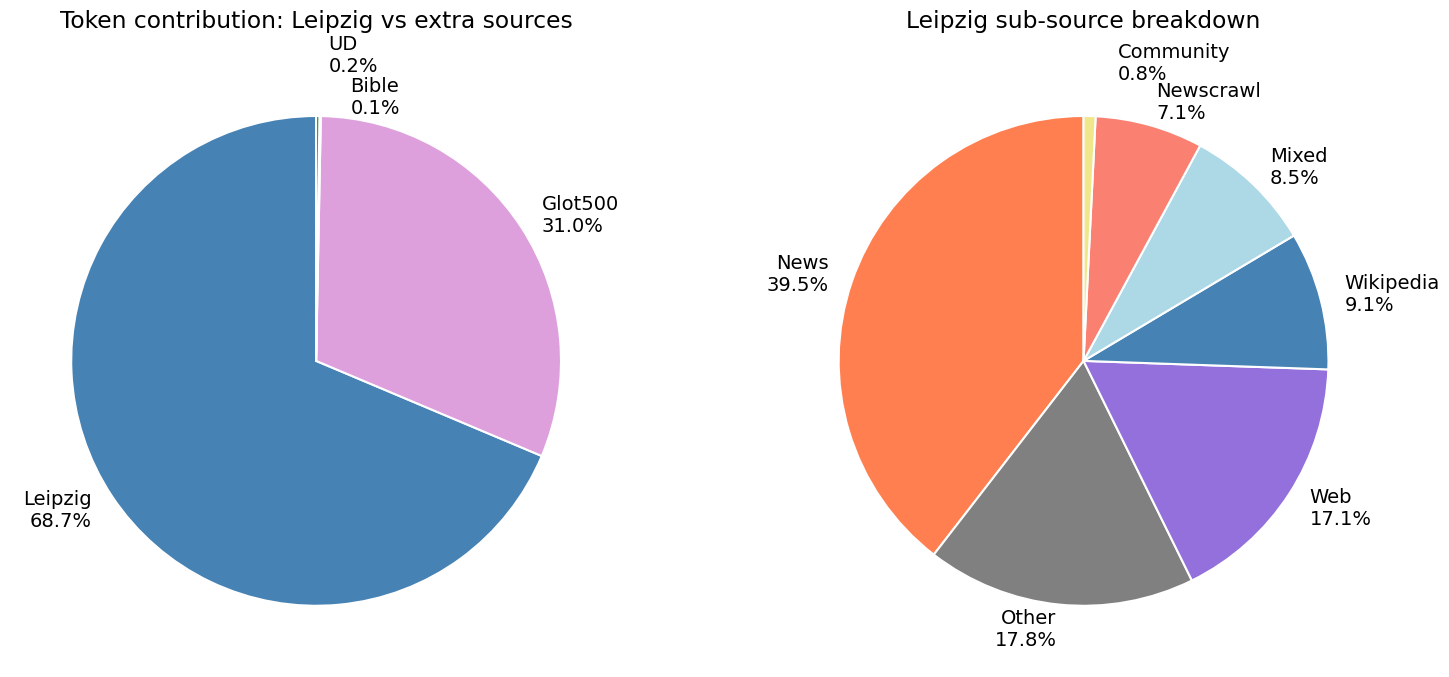

In [29]:
def source_total(source):
    return int(df_sources[source].sum()) if source in df_sources.columns else 0


def labels_with_percent(labels, sizes):
    total = sum(sizes)
    if total == 0:
        return list(labels)
    return [f"{label}\n{size / total * 100:.1f}%" for label, size in zip(labels, sizes)]


def draw_pie(ax, labels, sizes, title):
    filtered = [(l, s) for l, s in zip(labels, sizes) if s > 0]
    if not filtered:
        ax.set_title("No data")
        return
    labels, sizes = zip(*filtered)
    colors = [SOURCE_COLORS.get(l, "gray") for l in labels]

    _, texts = ax.pie(
        sizes, labels=labels_with_percent(labels, sizes), colors=colors,
        startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.5),
    )
    for text in texts:
        t = text.get_text()
        if t.startswith("UD"):
            text.set_position((0.05, 1.25))
            text.set_ha("left")
        elif t.startswith("Bible"):
            text.set_position((0.14, 1.08))
            text.set_ha("left")
        elif t.startswith("Community"):
            text.set_position((0.14, 1.22))
            text.set_ha("left")

    ax.set_title(title, pad=20)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

left_labels = ["Leipzig"] + [s for s in EXTRA_SOURCES if source_total(s) > 0]
left_sizes = [sum(source_total(s) for s in LEIPZIG_SOURCES)] + [source_total(s) for s in left_labels[1:]]
draw_pie(ax1, left_labels, left_sizes, "Token contribution: Leipzig vs extra sources")

right_labels = sorted(LEIPZIG_SOURCES, key=source_total, reverse=True)
right_sizes = [source_total(s) for s in right_labels]
draw_pie(ax2, right_labels, right_sizes, "Leipzig sub-source breakdown")

plt.tight_layout()
graph_export.save("data_sources", fig)
plt.show()